In [8]:
# baseline_tier_two.ipynb
# Tier 2 Baseline: Temporal Deep Learning (LSTM) with Socioeconomic Context

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt



In [9]:
# 1. DATA PREPARATION & SEQUENCING
class TrainDelaySequenceDataset(Dataset):
    def __init__(self, data, target_col, feature_cols, sequence_length=5):
        self.sequence_length = sequence_length
        self.target_col = target_col
        
        # We group by source-destination pairs or service IDs to create sequences
        # For this baseline, we assume the data is already sorted by time within groups
        self.features = data[feature_cols].values
        self.targets = data[target_col].values
        
        # Create sequences: [Batch, Sequence_Length, Features]
        self.X, self.y = [], []
        for i in range(len(data) - sequence_length):
            self.X.append(self.features[i : i + sequence_length])
            self.y.append(self.targets[i + sequence_length])
            
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



In [10]:
# 2. TIER 2 MODEL ARCHITECTURE (Derived from lstm_clas.py)
class DelayLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(DelayLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        # Use the last hidden state of the sequence
        out = out[:, -1, :]
        out = self.fc(out)
        return out



In [11]:
# 3. TRAINING AND COMPARISON LOGIC
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch).squeeze()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.numpy())
            
    return {
        'Balanced Accuracy': balanced_accuracy_score(all_targets, all_preds),
        'F1-Score': f1_score(all_targets, all_preds),
        'AUC': roc_auc_score(all_targets, all_probs)
    }



In [12]:
df = pd.read_parquet('C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/processed/final_dataset.parquet').fillna(0)

df.columns

Index(['Date', 'source', 'target', 'Rides planned', 'Final arrival delay',
       'Final arrival cancelled', 'Completely cancelled',
       'Intermediate arrival delays', 'Statistical Causes', 'Disruption Count',
       'DR', 'RH', 'SQ', 'TG', 'TN', 'TX', 'RHX', 'VVX', 'T10N', 'FHVEC',
       'Disrupted', 'year', 'source_WorkHistory_NotEmployed_Last4Y_pct',
       'source_WorkHistory_ConstantlyEmployed_Last4Y_pct',
       'source_WorkHistory_Retired_pct', 'source_Wealth_Percentile_1_40_pct',
       'source_Income_Avg_Percentile_Score', 'source_Edu_Low_pct',
       'source_Edu_High_Total_pct', 'source_PrivateHouseholds_Count',
       'source_SES_Score_WorkHistory_Avg', 'source_SES_Score_Wealth_Avg',
       'source_SES_Score_Education_Avg',
       'source_NetWorth_Avg_Percentile_Score', 'source_Population',
       'source_TotalPropertyDamageAndViolence_Index', 'source_BicycleTheft',
       'source_TotalVandalism', 'source_TotalViolentAndSexualCrimes',
       'source_TotalPropertyCrimes_R

Training Temporal Baseline...
Training Socio-Temporal Model...

Tier 2 Performance Metrics:
                      Balanced Accuracy  F1-Score       AUC
Temporal Baseline              0.593470  0.054184  0.643445
Socio-Temporal Model           0.541845  0.082610  0.621328


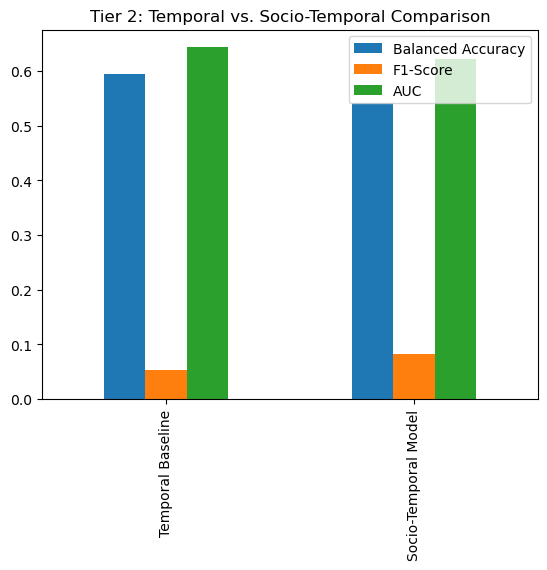

In [ ]:
# 4. EXECUTION SCRIPT

# Settings
SEQ_LENGTH = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 2
BATCH_SIZE = 64
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
df = pd.read_parquet('C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/processed/final_dataset.parquet').fillna(0)
target = 'Disrupted'

# Create the 'Remoteness' proxy identified in your EDA
if 'source_Dist_Highway_Entrance' in df.columns:
        df['source_Remoteness_Index'] = (df['source_Dist_Highway_Entrance'] + 
                                  df['source_Dist_Major_Transfer_Station']) / 2
        
        df['target_Remoteness_Index'] = (df['target_Dist_Highway_Entrance'] + 
                                  df['target_Dist_Major_Transfer_Station']) / 2
        
        

    
# Feature Groupings
base_features = ['Rides planned', 'disruption_count', 'stop_count', 'DR', 'RH', 'SQ', 'TG', 'TN', 'TX', 'RHX']
ses_features = ['target_SES_Score_Wealth_Avg', 'target_SES_Score_Education_Avg', 'target_TotalVandalism', 'target_Remoteness_Index',
                'source_SES_Score_Wealth_Avg', 'source_SES_Score_Education_Avg', 'source_TotalVandalism', 'source_Remoteness_Index']
    
scenarios = {
        "Temporal Baseline": base_features,
        "Socio-Temporal Model": base_features + ses_features
    }
    
results = {}

for name, features in scenarios.items():
    print(f"Training {name}...")
        
    # Scaling
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[features] = scaler.fit_transform(df[features])
        
    # Dataset split (Simple 80/20)
    split = int(0.8 * len(df_scaled))
    train_df = df_scaled.iloc[:split]
    test_df = df_scaled.iloc[split:]
        
    train_ds = TrainDelaySequenceDataset(train_df, target, features, SEQ_LENGTH)
    test_ds = TrainDelaySequenceDataset(test_df, target, features, SEQ_LENGTH)
        
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
        
    # Model Setup
    model = DelayLSTM(len(features), HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
        
    # Weighting classes for imbalance (based on your lstm_clas.py logic)
    pos_weight = torch.tensor([(df[target] == 0).sum() / (df[target] == 1).sum()]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
        
    # Train
    for epoch in range(EPOCHS):
        train_model(model, train_loader, criterion, optimizer, DEVICE)
            
    # Eval
    results[name] = evaluate_model(model, test_loader, DEVICE)

# Output Comparison
res_df = pd.DataFrame(results).T
print("\nTier 2 Performance Metrics:")
print(res_df)
res_df.plot(kind='bar', title='Tier 2: Temporal vs. Socio-Temporal Comparison')
plt.show()